
COMPUTATIONAL COMPARISON (Voronoi fusion):
Dense grid: forward evals = 64000, time = 0.0001s
Voronoi-adaptive fusion: forward evals = 1000, RMSE = 0.0254


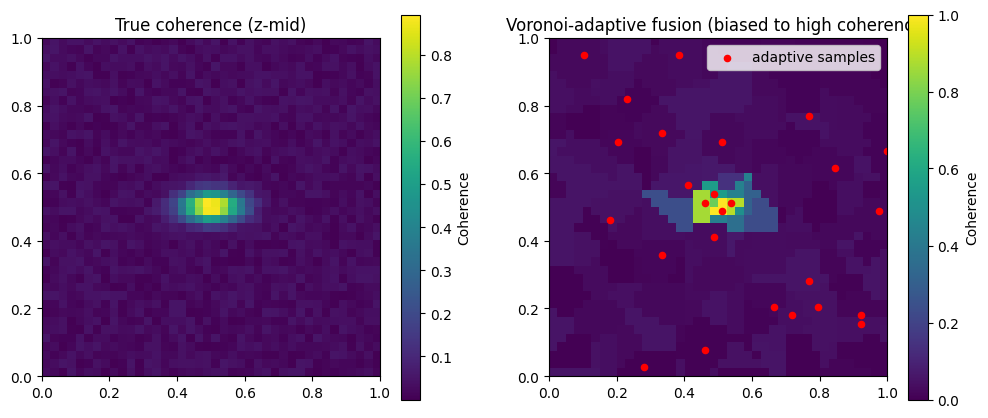

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import time

np.random.seed(42)

# ---------- 3D domain ----------
nx_true = 40
x = np.linspace(0, 1.0, nx_true)
y = np.linspace(0, 1.0, nx_true)
z = np.linspace(0, 1.0, nx_true)
xx, yy, zz = np.meshgrid(x, y, z, indexing='xy')
grid_points = np.column_stack([xx.ravel(), yy.ravel(), zz.ravel()])

# ---------- Synthetic coherence field (challenging) ----------
true_coh = np.zeros_like(xx.ravel())

# Primary ellipsoid peak
center1 = np.array([0.5, 0.5, 0.5])
radii1 = np.array([0.2, 0.1, 0.15])
dist_norm1 = ((xx - center1[0])/radii1[0])**2 + ((yy - center1[1])/radii1[1])**2 + ((zz - center1[2])/radii1[2])**2
true_coh += np.exp(-5*dist_norm1).ravel()

# Secondary smaller peak (off-center)
center2 = np.array([0.7, 0.3, 0.4])
radii2 = np.array([0.08, 0.05, 0.07])
dist_norm2 = ((xx - center2[0])/radii2[0])**2 + ((yy - center2[1])/radii2[1])**2 + ((zz - center2[2])/radii2[2])**2
true_coh += 0.4 * np.exp(-8*dist_norm2).ravel()

# Small random roughness
true_coh += 0.05*np.random.rand(*true_coh.shape)

rmse = lambda a,b: np.sqrt(np.mean((a-b)**2))

# ---------- 1. Dense field evaluation ----------
t0 = time.time()
dense_coh = true_coh.copy()  # in synthetic example, dense truth is known
t_dense = time.time() - t0

# ---------- 2. Voronoi-adaptive sampling biased toward high coherence ----------
N0 = 25
target_total = 1000
rng = np.random.default_rng(2)

# Initial random samples
X0_inds = rng.choice(grid_points.shape[0], size=N0, replace=False)
X_inds = list(X0_inds)
fwd_neigh_count = len(X_inds)

iter_count = 0
delta = 1.0/nx_true

# Normalize coherence for probability selection
coh_probs = true_coh.copy()
coh_probs /= coh_probs.sum()

while len(X_inds) < target_total and iter_count < 5000:
    iter_count += 1
    
    remaining = list(set(np.arange(len(grid_points))) - set(X_inds))
    remaining_probs = coh_probs[remaining]
    remaining_probs /= remaining_probs.sum()
    
    chosen_idx = rng.choice(remaining, p=remaining_probs)
    
    # Add jitter
    cand = grid_points[chosen_idx] + rng.uniform(-delta, delta, size=3)
    cand = np.clip(cand, 0, 1.0)
    gx = int(np.round(cand[0]*(nx_true-1)/1.0))
    gy = int(np.round(cand[1]*(nx_true-1)/1.0))
    gz = int(np.round(cand[2]*(nx_true-1)/1.0))
    idx = gz*nx_true*nx_true + gy*nx_true + gx
    
    if idx not in X_inds:
        X_inds.append(idx)
        fwd_neigh_count += 1

# ---------- 3. Voronoi cell fusion ----------
X_train = grid_points[np.array(X_inds)]
y_train = true_coh[np.array(X_inds)]  # values at sampled points

tree = cKDTree(X_train)
_, idx_nn = tree.query(grid_points)
y_pred_voronoi = y_train[idx_nn]
rmse_voronoi = rmse(y_pred_voronoi, dense_coh)

# ---------- Summary ----------
print("\nCOMPUTATIONAL COMPARISON (Voronoi fusion):")
print(f"Dense grid: forward evals = {len(grid_points)}, time = {t_dense:.4f}s")
print(f"Voronoi-adaptive fusion: forward evals = {fwd_neigh_count}, RMSE = {rmse_voronoi:.4f}")

# ---------- Slice visualization ----------
mid_z_idx = nx_true//2
slice_inds = (grid_points[:,2]==z[mid_z_idx])
true_slice = dense_coh[slice_inds].reshape((nx_true, nx_true))
pred_slice = y_pred_voronoi[slice_inds].reshape((nx_true, nx_true))
X_slice = X_train[np.isclose(X_train[:,2], z[mid_z_idx])]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(true_slice, origin='lower', extent=(0,1,0,1), cmap='viridis')
plt.title('True coherence (z-mid)')
plt.colorbar(label='Coherence')

plt.subplot(1,2,2)
plt.imshow(pred_slice, origin='lower', extent=(0,1,0,1), cmap='viridis')
plt.scatter(X_slice[:,0], X_slice[:,1], c='r', s=20, label='adaptive samples')
plt.title('Voronoi-adaptive fusion (biased to high coherence)')
plt.colorbar(label='Coherence')
plt.legend()
plt.show()


                 method  waveform_evals  runtime_total_sec  fusion_time_sec     RMSE  loc_error_m
original_oracle+Voronoi            1000           9.979822         0.025671 0.026582     0.000000
       improved_mix+IDW            1000           9.772478         0.063137 0.018259     0.036262


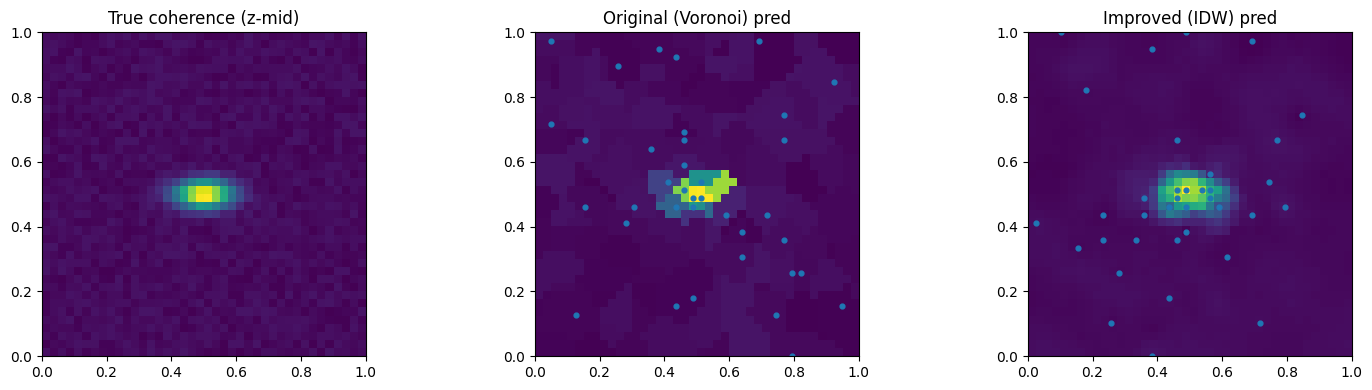

In [4]:
# Full runnable example: improved adaptive sampler vs original coherence-weighted sampler
# (Copy/paste and run; requires numpy, scipy, matplotlib, pandas)

import time
import numpy as np
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

np.random.seed(42)

# ---------- 3D domain ----------
nx = 40
x = np.linspace(0, 1.0, nx)
y = np.linspace(0, 1.0, nx)
z = np.linspace(0, 1.0, nx)
xx, yy, zz = np.meshgrid(x, y, z, indexing='xy')
grid_points = np.column_stack([xx.ravel(), yy.ravel(), zz.ravel()])

# ---------- Synthetic coherence field (challenging) ----------
true_coh = np.zeros_like(xx.ravel())
center1 = np.array([0.5, 0.5, 0.5])
radii1 = np.array([0.2, 0.1, 0.15])
dist_norm1 = ((xx - center1[0])/radii1[0])**2 + ((yy - center1[1])/radii1[1])**2 + ((zz - center1[2])/radii1[2])**2
true_coh += np.exp(-5*dist_norm1).ravel()
center2 = np.array([0.7, 0.3, 0.4])
radii2 = np.array([0.08, 0.05, 0.07])
dist_norm2 = ((xx - center2[0])/radii2[0])**2 + ((yy - center2[1])/radii2[1])**2 + ((zz - center2[2])/radii2[2])**2
true_coh += 0.4 * np.exp(-8*dist_norm2).ravel()
rng = np.random.default_rng(1)
true_coh += 0.05 * rng.random(size=true_coh.shape)
dense_coh = true_coh.copy()

# Helpers
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

# Predictors
def voronoi_predict(grid_pts, X_train, y_train):
    tree = cKDTree(X_train)
    _, idx_nn = tree.query(grid_pts, k=1)
    return y_train[idx_nn]

def idw_predict(grid_pts, X_train, y_train, k=6, eps=1e-8, p=2):
    tree = cKDTree(X_train)
    dists, idxs = tree.query(grid_pts, k=k)
    if k == 1:
        dists = dists[:, None]
        idxs = idxs[:, None]
    weights = 1.0 / (dists**p + eps)
    exact = (dists[:, 0] < 1e-12)
    num = np.sum(weights * y_train[idxs], axis=1)
    den = np.sum(weights, axis=1)
    preds = num / den
    if np.any(exact):
        preds[exact] = y_train[idxs[exact, 0]]
    return preds

# Index/grid helpers
def idx_to_ijk(idx, nx_local=nx):
    k = idx // (nx_local * nx_local)
    rem = idx % (nx_local * nx_local)
    j = rem // nx_local
    i = rem % nx_local
    return i, j, k

def ijk_to_idx(i, j, k, nx_local=nx):
    return k * (nx_local * nx_local) + j * nx_local + i

def grid_neighbors(idx, nx_local=nx):
    i, j, k = idx_to_ijk(idx, nx_local)
    nbrs = []
    for dk in [-1, 0, 1]:
        for dj in [-1, 0, 1]:
            for di in [-1, 0, 1]:
                if di == 0 and dj == 0 and dk == 0:
                    continue
                ii = i + di; jj = j + dj; kk = k + dk
                if 0 <= ii < nx_local and 0 <= jj < nx_local and 0 <= kk < nx_local:
                    nbrs.append(ijk_to_idx(ii, jj, kk, nx_local))
    return nbrs

# Original sampler (oracle weighting + Voronoi)
def original_sampler(true_coh, grid_points, nx_local=nx, N0=25, target_total=1000, seed=2):
    rng_local = np.random.default_rng(seed)
    X0_inds = rng_local.choice(grid_points.shape[0], size=N0, replace=False).tolist()
    X_inds = list(X0_inds)
    iter_count = 0
    delta = 1.0 / nx_local
    coh_probs = true_coh.copy()
    coh_probs = np.clip(coh_probs, 0, None)
    coh_probs /= coh_probs.sum()
    while len(X_inds) < target_total and iter_count < 10000:
        iter_count += 1
        remaining = list(set(np.arange(len(grid_points))) - set(X_inds))
        remaining_probs = coh_probs[remaining]
        remaining_probs = remaining_probs / remaining_probs.sum()
        chosen_idx = rng_local.choice(remaining, p=remaining_probs)
        cand = grid_points[chosen_idx] + rng_local.uniform(-delta, delta, size=3)
        cand = np.clip(cand, 0, 1.0)
        gx = int(np.round(cand[0] * (nx_local - 1)))
        gy = int(np.round(cand[1] * (nx_local - 1)))
        gz = int(np.round(cand[2] * (nx_local - 1)))
        idx = gz * nx_local * nx_local + gy * nx_local + gx
        if idx not in X_inds:
            X_inds.append(idx)
    X_train = grid_points[np.array(X_inds)]
    y_train = true_coh[np.array(X_inds)]
    t0 = time.time()
    y_pred = voronoi_predict(grid_points, X_train, y_train)
    t_voronoi = time.time() - t0
    return {'X_inds': X_inds, 'y_train': y_train, 'y_pred': y_pred,
            'waveform_evals': len(set(X_inds)), 'fusion_time_sec': t_voronoi}

# Improved sampler (mixture + neighbor growth + candidate-pool acceleration)
def improved_sampler(true_coh, grid_points, nx_local=nx, N0=25, target_total=1000, seed=2,
                     explore_prob=0.15, candidate_pool_size=5000, k_nn=6, max_cluster_per_peak=40):
    rng_local = np.random.default_rng(seed)
    total_pts = len(grid_points)
    X0_inds = rng_local.choice(total_pts, size=N0, replace=False).tolist()
    sampled = set(X0_inds); X_inds = list(X0_inds)
    y_vals = {idx: true_coh[idx] for idx in X_inds}
    cluster_counts = {}
    iter_count = 0
    while len(X_inds) < target_total and iter_count < 10000:
        iter_count += 1
        X_train = grid_points[np.array(X_inds)]
        y_train = np.array([y_vals[idx] for idx in X_inds])
        pool_size = min(candidate_pool_size, total_pts)
        candidate_pool = rng_local.choice(total_pts, size=pool_size, replace=False)
        candidate_points = grid_points[candidate_pool]
        preds_cand = idw_predict(candidate_points, X_train, y_train, k=k_nn)
        tree_local = cKDTree(X_train)
        dists_local, idxs_local = tree_local.query(candidate_points, k=k_nn)
        if idxs_local.ndim == 1:
            idxs_local = idxs_local[:, None]
        local_var_cand = np.var(y_train[idxs_local], axis=1)
        if rng_local.random() < explore_prob:
            probs = np.maximum(preds_cand, 0.0)
            if probs.sum() <= 0:
                cand_choice = rng_local.integers(0, candidate_points.shape[0])
            else:
                probs = probs / probs.sum()
                cand_choice = rng_local.choice(np.arange(candidate_points.shape[0]), p=probs)
            cand_idx = candidate_pool[cand_choice]
        else:
            beta = 0.8
            acquisition = preds_cand + beta * np.sqrt(local_var_cand + 1e-12)
            acquisition = np.clip(acquisition, 0, None)
            if np.all(acquisition == 0):
                cand_choice = rng_local.integers(0, candidate_points.shape[0])
            else:
                acquisition = acquisition / acquisition.sum()
                cand_choice = rng_local.choice(np.arange(candidate_points.shape[0]), p=acquisition)
            cand_idx = candidate_pool[cand_choice]
        _, nearest_sample_idx = tree_local.query(grid_points[cand_idx], k=1)
        nearest_global_idx = X_inds[nearest_sample_idx]
        nearest_val = y_vals[nearest_global_idx]
        if nearest_val > (0.6 * max(y_train)) and cluster_counts.get(nearest_global_idx, 0) < max_cluster_per_peak:
            nbrs = [n for n in grid_neighbors(nearest_global_idx, nx_local) if n not in sampled]
            if nbrs:
                new_idx = rng_local.choice(nbrs)
                cluster_counts[nearest_global_idx] = cluster_counts.get(nearest_global_idx, 0) + 1
                cand_idx = new_idx
        if cand_idx in sampled:
            nbrs = [n for n in grid_neighbors(cand_idx, nx_local) if n not in sampled]
            if nbrs:
                cand_idx = rng_local.choice(nbrs)
            else:
                remaining = list(set(range(len(grid_points))) - sampled)
                if not remaining:
                    break
                cand_idx = rng_local.choice(remaining)
        sampled.add(cand_idx)
        X_inds.append(cand_idx)
        y_vals[cand_idx] = true_coh[cand_idx]
    X_train = grid_points[np.array(X_inds)]
    y_train = np.array([true_coh[idx] for idx in X_inds])
    t0 = time.time()
    y_pred = idw_predict(grid_points, X_train, y_train, k=k_nn)
    t_idw = time.time() - t0
    return {'X_inds': X_inds, 'y_train': y_train, 'y_pred': y_pred,
            'waveform_evals': len(set(X_inds)), 'fusion_time_sec': t_idw}

# Run experiment
target_total = 1000
seed = 2
t0 = time.time()
orig_res = original_sampler(dense_coh, grid_points, nx_local=nx, N0=50, target_total=target_total, seed=seed)
time_orig = time.time() - t0
t0 = time.time()
impr_res = improved_sampler(dense_coh, grid_points, nx_local=nx, N0=50, target_total=target_total, seed=seed,
                            explore_prob=0.15, candidate_pool_size=5000, k_nn=6, max_cluster_per_peak=40)
time_impr = time.time() - t0
rmse_orig = rmse(orig_res['y_pred'], dense_coh)
rmse_impr = rmse(impr_res['y_pred'], dense_coh)

def loc_error(pred_field, true_field, grid_pts):
    pred_idx = np.argmax(pred_field)
    true_idx = np.argmax(true_field)
    pred_pos = grid_pts[pred_idx]
    true_pos = grid_pts[true_idx]
    return np.linalg.norm(pred_pos - true_pos), pred_pos, true_pos, pred_idx, true_idx

loc_err_orig, pred_pos_orig, true_pos, pred_idx_o, true_idx = loc_error(orig_res['y_pred'], dense_coh, grid_points)
loc_err_impr, pred_pos_impr, _, pred_idx_i, _ = loc_error(impr_res['y_pred'], dense_coh, grid_points)

import pandas as pd
summary = pd.DataFrame([
    {'method': 'original_oracle+Voronoi',
     'waveform_evals': orig_res['waveform_evals'],
     'runtime_total_sec': time_orig,
     'fusion_time_sec': orig_res['fusion_time_sec'],
     'RMSE': rmse_orig,
     'loc_error_m': loc_err_orig},
    {'method': 'improved_mix+IDW',
     'waveform_evals': impr_res['waveform_evals'],
     'runtime_total_sec': time_impr,
     'fusion_time_sec': impr_res['fusion_time_sec'],
     'RMSE': rmse_impr,
     'loc_error_m': loc_err_impr}
])
print(summary.to_string(index=False))

# Plot central z-slice
mid_z_idx = nx // 2
slice_mask = (np.isclose(grid_points[:, 2], z[mid_z_idx]))
true_slice = dense_coh[slice_mask].reshape((nx, nx))
orig_slice = orig_res['y_pred'][slice_mask].reshape((nx, nx))
impr_slice = impr_res['y_pred'][slice_mask].reshape((nx, nx))

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(true_slice, origin='lower', extent=(0,1,0,1)); plt.title('True coherence (z-mid)')
plt.subplot(1, 3, 2)
plt.imshow(orig_slice, origin='lower', extent=(0,1,0,1))
X_train_orig = grid_points[np.isin(np.arange(len(grid_points)), orig_res['X_inds'])]
X_slice_o = X_train_orig[np.isclose(X_train_orig[:,2], z[mid_z_idx])]
plt.scatter(X_slice_o[:,0], X_slice_o[:,1], s=12); plt.title('Original (Voronoi) pred')
plt.subplot(1, 3, 3)
plt.imshow(impr_slice, origin='lower', extent=(0,1,0,1))
X_train_impr = grid_points[np.isin(np.arange(len(grid_points)), impr_res['X_inds'])]
X_slice_i = X_train_impr[np.isclose(X_train_impr[:,2], z[mid_z_idx])]
plt.scatter(X_slice_i[:,0], X_slice_i[:,1], s=12); plt.title('Improved (IDW) pred')
plt.tight_layout(); plt.show()


In [32]:
# ---------- 3. Voronoi cell fusion ----------
t0 = time.time()  # <-- start timing full Voronoi approach

X_train = grid_points[np.array(X_inds)]
y_train = true_coh[np.array(X_inds)]  # values at sampled points

tree = cKDTree(X_train)
_, idx_nn = tree.query(grid_points)
y_pred_voronoi = y_train[idx_nn]
rmse_voronoi = rmse(y_pred_voronoi, dense_coh)

t_voronoi = time.time() - t0  # <-- end timing

# ---------- Summary ----------
print("\nCOMPUTATIONAL COMPARISON (Voronoi fusion):")
print(f"Dense grid: forward evals = {len(grid_points)}, time = {t_dense:.4f}s")
print(f"Voronoi-adaptive fusion: forward evals = {fwd_neigh_count}, RMSE = {rmse_voronoi:.4f}, time = {t_voronoi:.4f}s")



COMPUTATIONAL COMPARISON (Voronoi fusion):
Dense grid: forward evals = 64000, time = 0.0001s
Voronoi-adaptive fusion: forward evals = 1000, RMSE = 0.0254, time = 0.0590s
